In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

In [2]:
path = kagglehub.dataset_download("mukaffimoin/potato-diseases-datasets")
print("Dataset path:", path)
print("Isi folder di root:", os.listdir(path))

# Folder root dataset
ROOT_DIR = path
HEALTHY = "Healthy Potatoes"

# Parameter eksperimen
IMG_SIZE   = 256
BATCH_SIZE = 8
EPOCHS     = 500
SEED       = 42

Using Colab cache for faster access to the 'potato-diseases-datasets' dataset.
Dataset path: /kaggle/input/potato-diseases-datasets
Isi folder di root: ['Black Scurf', 'Blackleg', 'Common Scab', 'Pink Rot', 'Dry Rot', 'Miscellaneous', 'Healthy Potatoes']


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2,
    rotation_range=8,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=0.05,
    horizontal_flip=True,
    brightness_range=[0.75, 1.25],
    channel_shift_range=25.0
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    ROOT_DIR,
    classes=[HEALTHY],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    ROOT_DIR,
    classes=[HEALTHY],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation",
    shuffle=False,
    seed=SEED
)

steps_per_epoch    = max(1, train_gen.samples // BATCH_SIZE)
validation_steps   = max(1, val_gen.samples // BATCH_SIZE)
print("Jumlah train:", train_gen.samples, " | Jumlah val:", val_gen.samples)

Found 64 images belonging to 1 classes.
Found 16 images belonging to 1 classes.
Jumlah train: 64  | Jumlah val: 16


In [4]:
# Random Masking untuk Inpainting
def random_cutout_with_mask(img, min_frac=0.10, max_frac=0.20):
    h, w, _ = img.shape

    mask_h = np.random.randint(int(h * min_frac), int(h * max_frac))
    mask_w = np.random.randint(int(w * min_frac), int(w * max_frac))

    y = np.random.randint(0, h - mask_h)
    x = np.random.randint(0, w - mask_w)

    out = img.copy()
    out[y:y + mask_h, x:x + mask_w, :] = 0.0

    # mask: 1 = area yang di-mask (harus direkonstruksi), 0 = area asli
    mask = np.zeros((h, w, 1), dtype=np.float32)
    mask[y:y + mask_h, x:x + mask_w, :] = 1.0
    return out, mask

def masked_generator(gen):
    while True:
        batch, _ = next(gen)
        masked = []
        targets = []
        for img in batch:
            m_img, mask = random_cutout_with_mask(img)
            masked.append(m_img)
            combined_target = np.concatenate([img, mask], axis=-1)
            targets.append(combined_target)
        yield np.array(masked), np.array(targets)

train_masked = masked_generator(train_gen)
val_masked   = masked_generator(val_gen)

In [5]:
# UNET AUTOENCODER untuk Kentang
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.GroupNormalization(groups=8)(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.GroupNormalization(groups=8)(x)
    x = layers.Activation("relu")(x)
    return x

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 256)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    b = conv_block(p4, 512)
    b = layers.Dropout(0.3)(b)

    # Decoder
    u4 = layers.UpSampling2D((2, 2))(b)
    u4 = layers.Concatenate()([u4, c4])
    d4 = conv_block(u4, 256)

    u3 = layers.UpSampling2D((2, 2))(d4)
    u3 = layers.Concatenate()([u3, c3])
    d3 = conv_block(u3, 128)

    u2 = layers.UpSampling2D((2, 2))(d3)
    u2 = layers.Concatenate()([u2, c2])
    d2 = conv_block(u2, 64)

    u1 = layers.UpSampling2D((2, 2))(d2)
    u1 = layers.Concatenate()([u1, c1])
    d1 = conv_block(u1, 32)

    outputs = layers.Conv2D(3, 1, activation="sigmoid")(d1)

    model = models.Model(inputs, outputs, name="unet_inpainting")
    return model


autoencoder = build_unet()
autoencoder.summary()

Model: "unet_inpainting"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalization │ (None, 256, 256,  │         64 │ conv2d[0][0]      │
│ (GroupNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ group_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_1[0][0]    │
│ (GroupNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ group_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (GroupNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ group_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_3[0][0]    │
│ (GroupNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ group_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_4[0][0]  

 Total params: 7,852,611 (29.96 MB)

 Trainable params: 7,852,611 (29.96 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
def ssim_loss(y_true_img, y_pred_img):
    s = tf.image.ssim(y_true_img, y_pred_img, max_val=1.0)
    return 1.0 - tf.reduce_mean(s)

def combined_loss(y_true, y_pred):
    y_true_img = y_true[..., :3]   # 3 channel pertama = ground truth
    mask       = y_true[..., 3:4]  # channel ke-4 = mask (1=area rusak, 0=area asli)

    mae_map = tf.abs(y_true_img - y_pred)           # (B,H,W,3)
    mask_b  = tf.broadcast_to(mask, tf.shape(mae_map))

    weight_inside  = 1.5   # bobot lebih besar di area yang di-mask
    weight_outside = 1.0
    weights = mask_b * weight_inside + (1.0 - mask_b) * weight_outside

    weighted_mae = tf.reduce_sum(mae_map * weights) / tf.reduce_sum(weights)
    s_loss = ssim_loss(y_true_img, y_pred)

    return 0.35 * weighted_mae + 0.65 * s_loss

def mae_metric(y_true, y_pred):
    y_true_img = y_true[..., :3]
    return tf.reduce_mean(tf.abs(y_true_img - y_pred))

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=4e-4),
    loss=combined_loss,
    metrics=[mae_metric]
)

In [7]:
# Callback
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=50,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "best_unet_inpainting.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

# Training
history = autoencoder.fit(
    train_masked,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_masked,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 59s 833ms/step - loss: 0.3952 - mae_metric: 0.3804 - val_loss: 0.3209 - val_mae_metric: 0.3083 - learning_rate: 4.0000e-04
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 409ms/step - loss: 0.2309 - mae_metric: 0.2585 - val_loss: 0.2582 - val_mae_metric: 0.2723 - learning_rate: 4.0000e-04
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 329ms/step - loss: 0.1797 - mae_metric: 0.2107 - val_loss: 0.2184 - val_mae_metric: 0.2450 - learning_rate: 4.0000e-04
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - loss: 0.1680 - mae_metric: 0.2124 - val_loss: 0.1981 - val_mae_metric: 0.2300 - learning_rate: 4.0000e-04
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 334ms/step - loss: 0.1485 - mae_metric: 0.1974 - val_loss: 0.1782 - val_mae_metric: 0.2162 - learning_rate: 4.0000e-04
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 400ms/step - loss: 0.1310 - mae_metric: 0.1668 - val_loss: 0.1542 - val_mae_metric: 0.1922 - learning_rate: 4.0000e-04
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 348ms

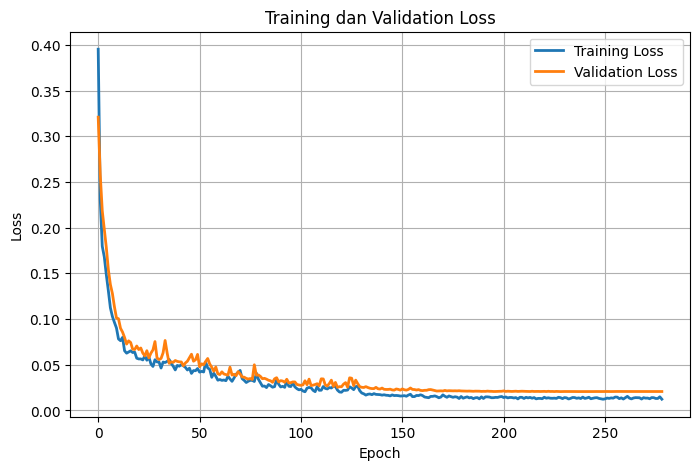

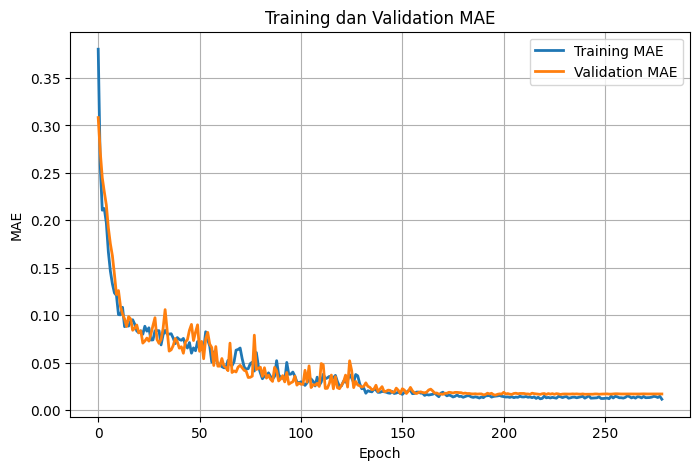

In [8]:
# VISUALISASI
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training dan Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["mae_metric"], label="Training MAE", linewidth=2)
plt.plot(history.history["val_mae_metric"], label="Validation MAE", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training dan Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


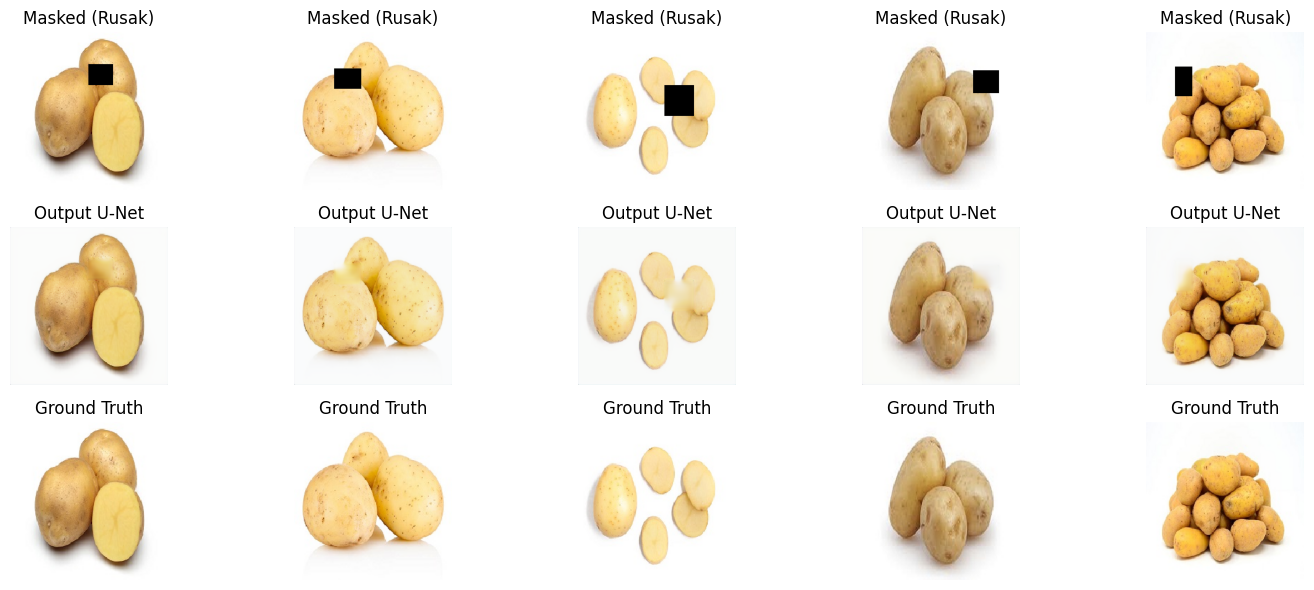

In [9]:
# Ambil sampel dari validation set (citra sehat)
batch, _ = next(val_gen)
sample = batch[:5]

masked_sample = np.array([random_cutout_with_mask(img)[0] for img in sample])
reconstructed = np.clip(autoencoder.predict(masked_sample), 0.0, 1.0)

plt.figure(figsize=(15, 6))

for i in range(len(sample)):
    # masked
    plt.subplot(3, len(sample), i + 1)
    plt.imshow(masked_sample[i])
    plt.title("Masked (Rusak)")
    plt.axis("off")

    # output unet
    plt.subplot(3, len(sample), len(sample) + i + 1)
    plt.imshow(reconstructed[i])
    plt.title("Output U-Net")
    plt.axis("off")

    # original healthy
    plt.subplot(3, len(sample), 2 * len(sample) + i + 1)
    plt.imshow(sample[i])
    plt.title("Ground Truth")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
ssim_scores = []
psnr_scores = []

val_gen.reset()
for _ in range(len(val_gen)):
    batch, _ = next(val_gen)
    masked_batch = np.array([random_cutout_with_mask(img)[0] for img in batch])
    recon_batch = np.clip(autoencoder.predict(masked_batch, verbose=0), 0.0, 1.0)

    for i in range(len(batch)):
        s_val = ssim(batch[i], recon_batch[i], channel_axis=-1, data_range=1.0)
        p_val = psnr(batch[i], recon_batch[i], data_range=1.0)
        ssim_scores.append(s_val)
        psnr_scores.append(p_val)

print("Rata-rata SSIM (seluruh val set):", np.mean(ssim_scores))
print("Rata-rata PSNR (seluruh val set):", np.mean(psnr_scores))

Rata-rata SSIM (seluruh val set): 0.9766882
Rata-rata PSNR (seluruh val set): 32.456067695924844
